# Classification de Tumeurs Mammaires (Bénignes / Malignes)

**Dataset :** Breast Cancer Wisconsin (Diagnostic) — [UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic))  
**Modèles :** SVM · Random Forest · MLP

---

## 1. Chargement des Données & Analyse Exploratoire (EDA)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

# Reproducibility
np.random.seed(42)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

In [5]:
# Load dataset
cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target           # 0 = malignant, 1 = benign
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print(f'Dataset shape : {df.shape}')
print(f'Features      : {cancer.feature_names.tolist()}')
df.head()

Dataset shape : (569, 32)
Features      : ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


Class distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


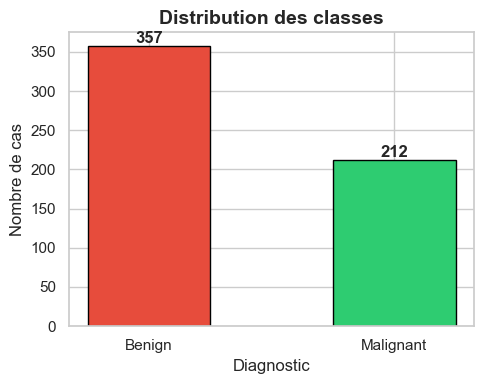

In [7]:
# Class distribution
counts = df['diagnosis'].value_counts()
print('Class distribution:')
print(counts)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
ax.set_title('Distribution des classes', fontsize=14, fontweight='bold')
ax.set_xlabel('Diagnostic')
ax.set_ylabel('Nombre de cas')
for i, v in enumerate(counts.values):
    ax.text(i, v + 4, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Descriptive statistics
df.drop(columns=['target', 'diagnosis']).describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [9]:
# Check for missing values
missing = df.isnull().sum().sum()
print(f'Missing values: {missing}  — Dataset is complete.')

Missing values: 0  — Dataset is complete.


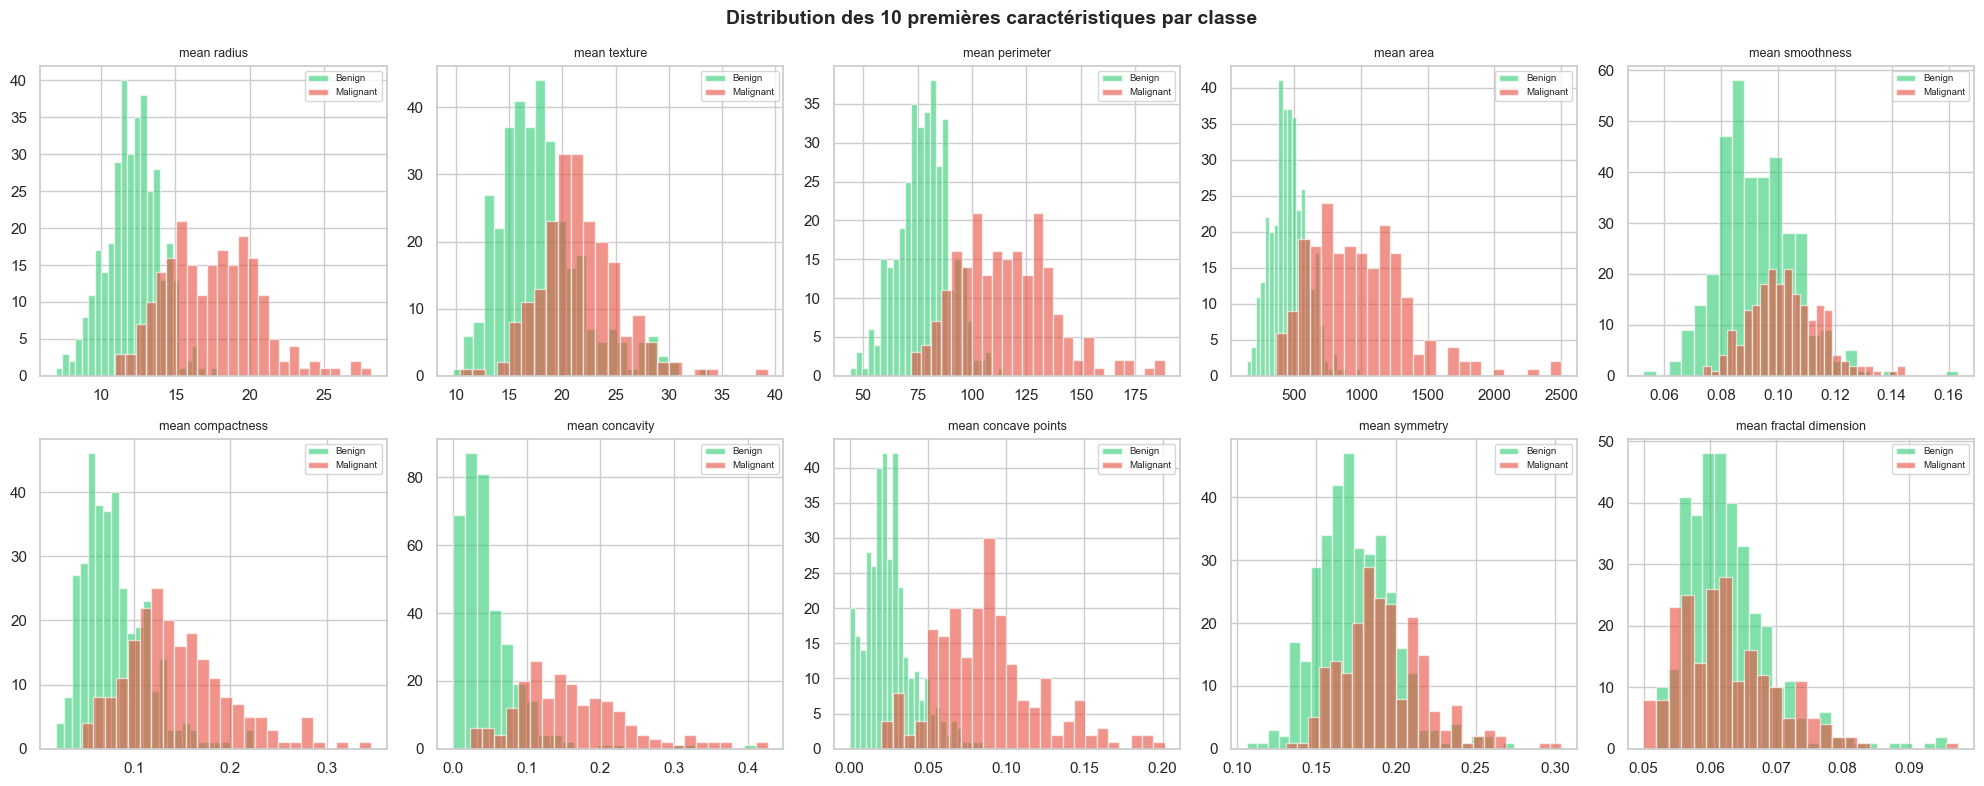

In [10]:
# Distribution of first 10 features by class
top_features = cancer.feature_names[:10].tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    for label, color in zip(['Benign', 'Malignant'], ['#2ecc71', '#e74c3c']):
        axes[i].hist(df[df['diagnosis'] == label][feat], bins=25,
                     alpha=0.6, label=label, color=color, edgecolor='white')
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)

fig.suptitle('Distribution des 10 premières caractéristiques par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

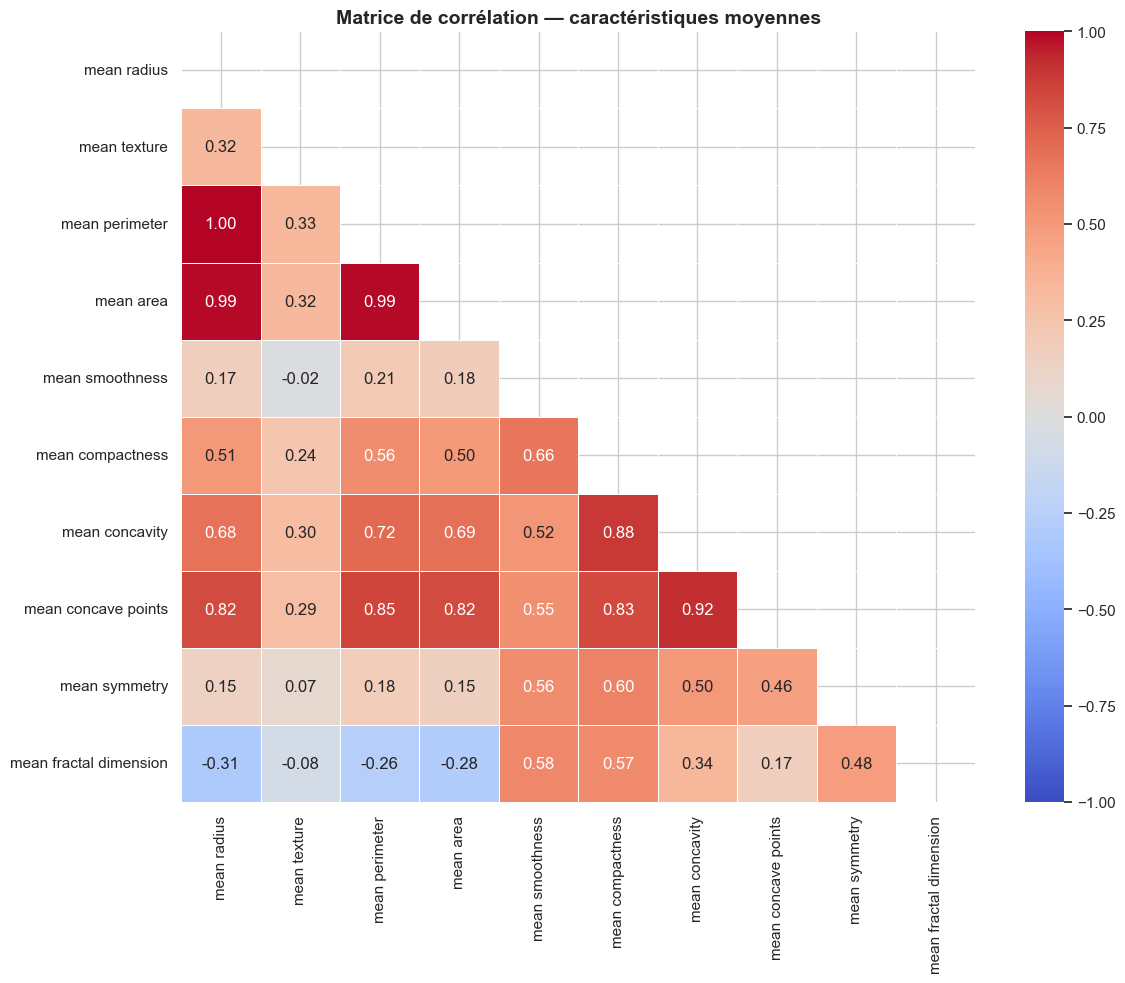

In [11]:
# Correlation heatmap (mean features only)
mean_cols = [c for c in df.columns if 'mean' in c]
corr = df[mean_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matrice de corrélation — caractéristiques moyennes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

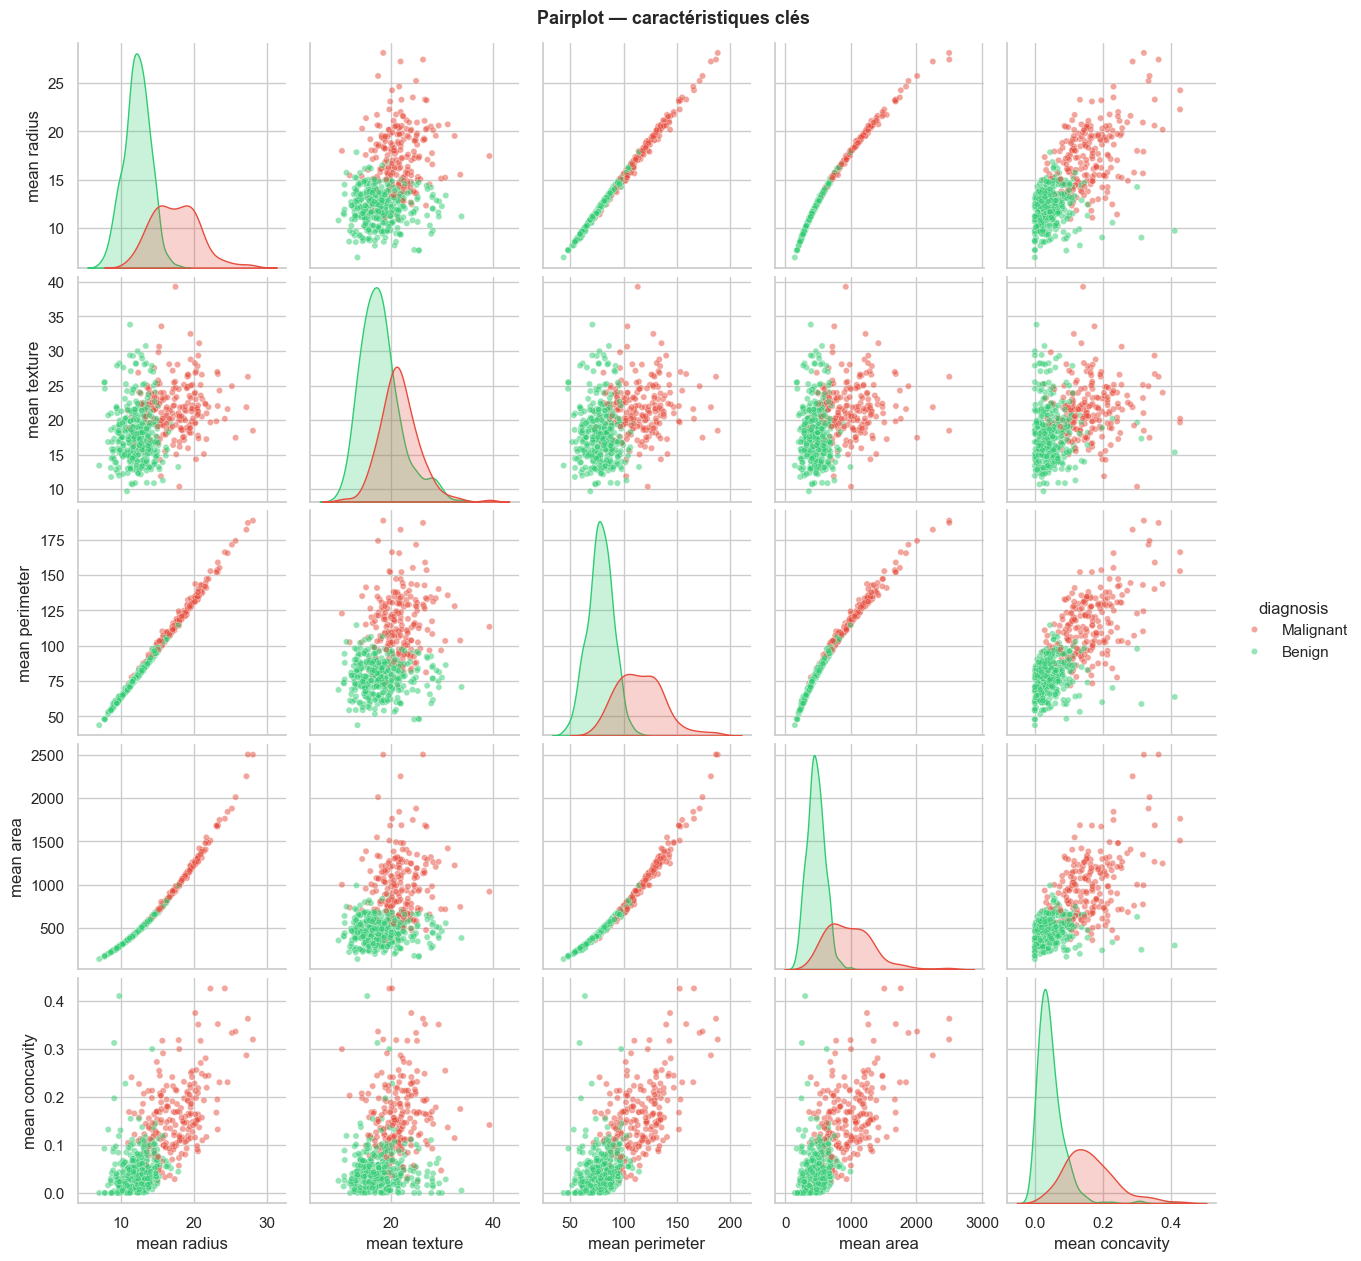

In [12]:
# Pairplot of top 5 most discriminative features
key_feats = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean concavity']
pair_df = df[key_feats + ['diagnosis']]

sns.pairplot(pair_df, hue='diagnosis', palette={'Benign': '#2ecc71', 'Malignant': '#e74c3c'},
             plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Pairplot — caractéristiques clés', y=1.01, fontsize=13, fontweight='bold')
plt.show()

---
## 2. Prétraitement des Données

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [14]:
# Features & target
X = cancer.data
y = cancer.target   # 0 = malignant, 1 = benign

# Train / Test split  (80 / 20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]} samples')
print(f'Test  size : {X_test.shape[0]} samples')
print(f'Train class ratio — Benign: {y_train.mean():.2%}  Malignant: {1 - y_train.mean():.2%}')

Train size : 455 samples
Test  size : 114 samples
Train class ratio — Benign: 62.64%  Malignant: 37.36%


In [15]:
# Standard scaling (fit on train only → transform both sets)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Scaled train mean  ≈', X_train_sc.mean(axis=0)[:5].round(4))
print('Scaled train std   ≈', X_train_sc.std(axis=0)[:5].round(4))

Scaled train mean  ≈ [-0.  0. -0.  0.  0.]
Scaled train std   ≈ [1. 1. 1. 1. 1.]


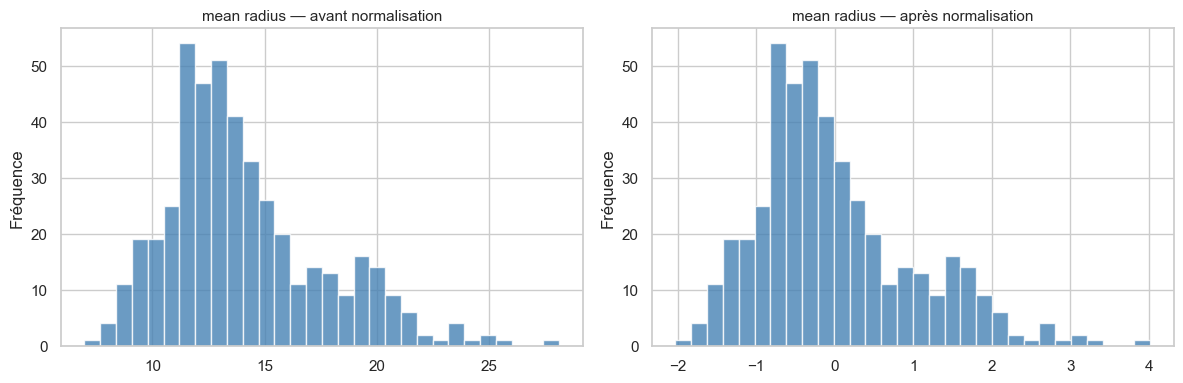

In [12]:
# Visualise effect of scaling on first feature
feat_idx = 0
feat_name = cancer.feature_names[feat_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title in zip(
    axes,
    [X_train[:, feat_idx], X_train_sc[:, feat_idx]],
    [f'{feat_name} — avant normalisation', f'{feat_name} — après normalisation']
):
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

---
## 2.5 Réduction de Dimensionnalité — ACP (PCA)

La matrice de corrélation révèle de fortes colinéarités entre les variables (ex. rayon, périmètre, aire). L'ACP permet de projeter les 30 caractéristiques dans un espace de dimension réduite tout en conservant l'essentiel de l'information.

In [ ]:
from sklearn.decomposition import PCA

# Fit PCA on all 30 scaled features to analyse explained variance
pca_full = PCA().fit(X_train_sc)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)

n_components_95 = int(np.argmax(cumvar >= 0.95) + 1)
n_components_99 = int(np.argmax(cumvar >= 0.99) + 1)

print(f'Composantes pour 95 % de variance : {n_components_95}')
print(f'Composantes pour 99 % de variance : {n_components_99}')
print(f'Réduction retenue : 30 → {n_components_95} composantes '
      f'({(1 - n_components_95 / 30) * 100:.1f} % de réduction)')

# Scree plot + cumulative variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 31), pca_full.explained_variance_ratio_,
            color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Variance expliquée par composante', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Ratio de variance expliquée')

axes[1].plot(range(1, 31), cumvar, 'o-', color='royalblue', lw=2)
axes[1].axhline(0.95, color='red',    ls='--', lw=1.5, label='Seuil 95 %')
axes[1].axhline(0.99, color='orange', ls='--', lw=1.5, label='Seuil 99 %')
axes[1].axvline(n_components_95, color='red',    ls=':', alpha=0.6)
axes[1].axvline(n_components_99, color='orange', ls=':', alpha=0.6)
axes[1].set_title('Variance cumulée expliquée', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Apply PCA (95 % variance threshold) — fit on train, transform both sets
pca = PCA(n_components=n_components_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

print(f'Forme avant ACP : {X_train_sc.shape}  →  après ACP : {X_train_pca.shape}')

# 2-D projection (PC1 vs PC2) coloured by class
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], ['#e74c3c', '#2ecc71'], ['Malignant', 'Benign']):
    mask = y_train == label
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
               alpha=0.6, s=30, color=color, label=name, edgecolors='white', linewidths=0.3)

ax.set_title('ACP — Projection 2D (PC1 vs PC2)', fontsize=13, fontweight='bold')
ax.set_xlabel('Composante principale 1')
ax.set_ylabel('Composante principale 2')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Modèle SVM (Support Vector Machine)

In [16]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

In [ ]:
# Hyperparameter tuning via Grid Search + 5-fold CV
param_grid_svm = {
    'C'     : [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma' : ['scale', 'auto']
}

gs_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_svm.fit(X_train_pca, y_train)

print(f'Best SVM params   : {gs_svm.best_params_}')
print(f'Best CV accuracy  : {gs_svm.best_score_:.4f}')

In [ ]:
# Evaluate best SVM on test set
svm_best = gs_svm.best_estimator_
y_pred_svm  = svm_best.predict(X_test_pca)
y_prob_svm  = svm_best.predict_proba(X_test_pca)[:, 1]

acc_svm = accuracy_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

print(f'SVM — Test Accuracy : {acc_svm:.4f}')
print(f'SVM — ROC-AUC       : {auc_svm:.4f}')
print()
print(classification_report(y_test, y_pred_svm, target_names=cancer.target_names))

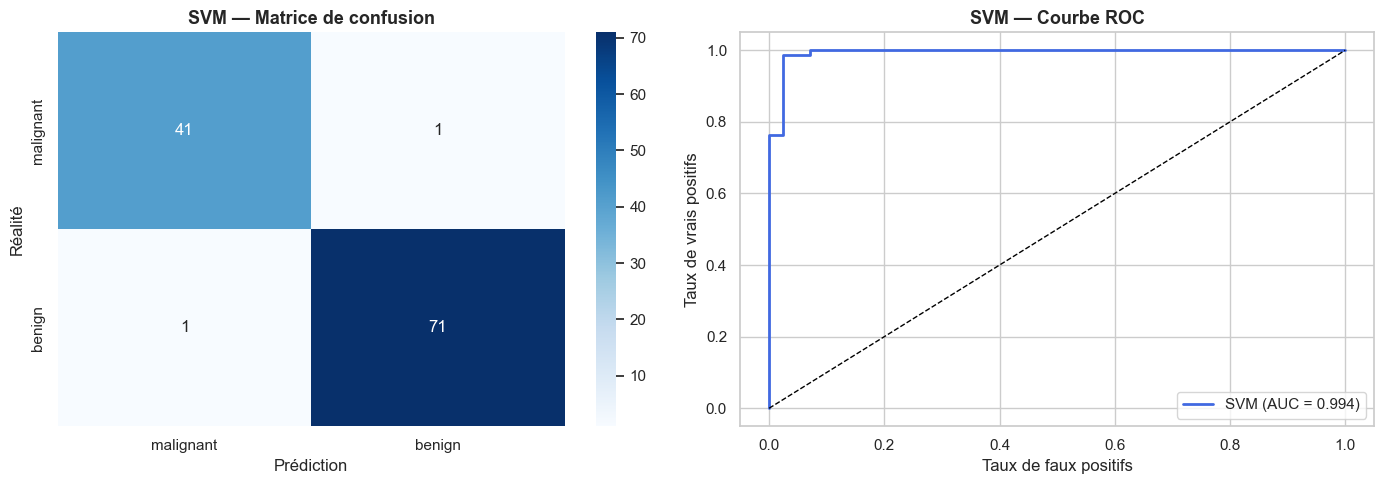

In [20]:
# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion matrix ---
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names, ax=axes[0])
axes[0].set_title('SVM — Matrice de confusion', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prédiction')
axes[0].set_ylabel('Réalité')

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
axes[1].plot(fpr, tpr, color='royalblue', lw=2, label=f'SVM (AUC = {auc_svm:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('SVM — Courbe ROC', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Taux de faux positifs')
axes[1].set_ylabel('Taux de vrais positifs')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

---
## 4. Modèle Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Hyperparameter tuning
param_grid_rf = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 'log2']
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_rf.fit(X_train_pca, y_train)

print(f'Best RF params   : {gs_rf.best_params_}')
print(f'Best CV accuracy : {gs_rf.best_score_:.4f}')

In [ ]:
# Evaluate best RF on test set
rf_best = gs_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test_pca)
y_prob_rf = rf_best.predict_proba(X_test_pca)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f'Random Forest — Test Accuracy : {acc_rf:.4f}')
print(f'Random Forest — ROC-AUC       : {auc_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=cancer.target_names))

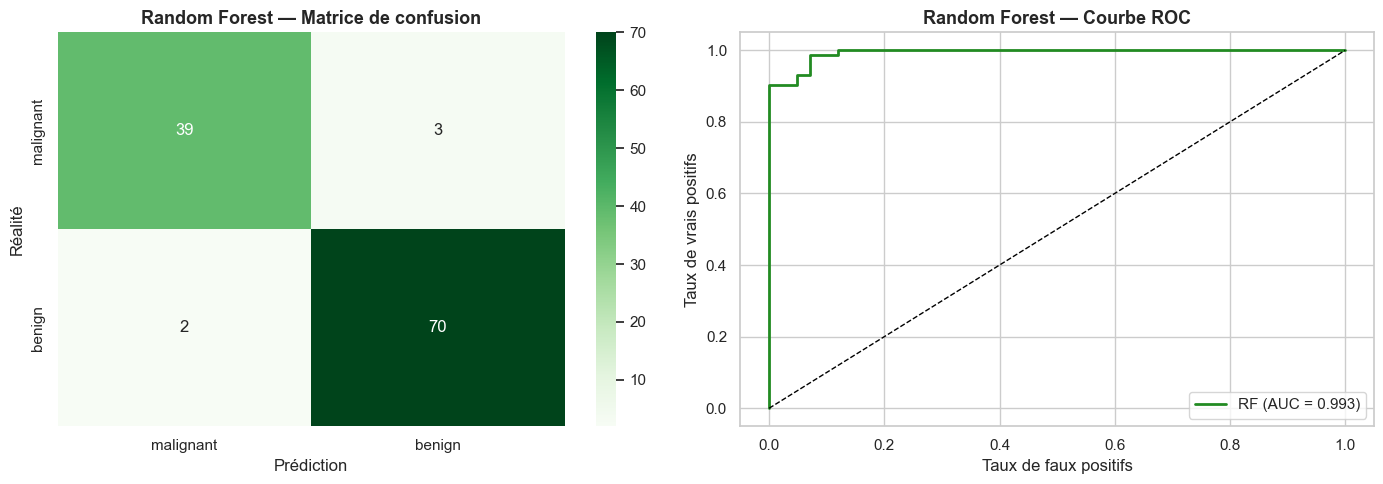

In [25]:
# Confusion matrix + ROC
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names, ax=axes[0])
axes[0].set_title('Random Forest — Matrice de confusion', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prédiction')
axes[0].set_ylabel('Réalité')

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
axes[1].plot(fpr_rf, tpr_rf, color='forestgreen', lw=2, label=f'RF (AUC = {auc_rf:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('Random Forest — Courbe ROC', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Taux de faux positifs')
axes[1].set_ylabel('Taux de vrais positifs')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

C:\Users\ahass\AppData\Local\Temp\ipykernel_18696\3563771443.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='importance', y='feature', palette='viridis', ax=ax)


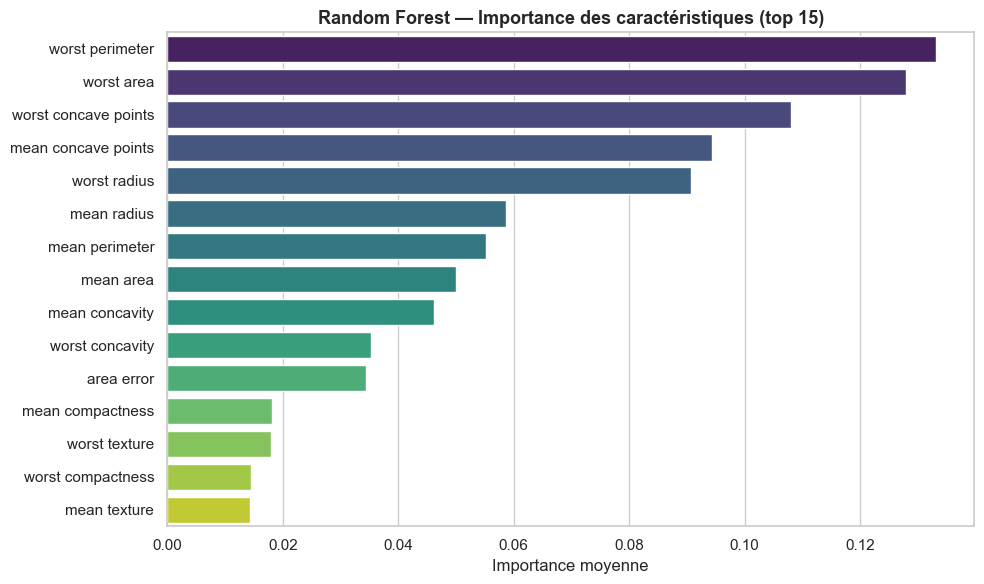

In [26]:
# Feature importance (top 15)
importances = rf_best.feature_importances_
feat_imp_df = pd.DataFrame({
    'feature'   : cancer.feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('Random Forest — Importance des caractéristiques (top 15)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance moyenne')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## 5. Modèle MLP (Réseau de Neurones Multicouche)

In [27]:
from sklearn.neural_network import MLPClassifier

In [ ]:
# Hyperparameter tuning
param_grid_mlp = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
    'activation'        : ['relu', 'tanh'],
    'alpha'             : [1e-4, 1e-3, 1e-2],
    'learning_rate_init': [1e-3, 1e-2]
}

gs_mlp = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=42, early_stopping=True,
                  validation_fraction=0.1, n_iter_no_change=10),
    param_grid_mlp,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_mlp.fit(X_train_pca, y_train)

print(f'Best MLP params   : {gs_mlp.best_params_}')
print(f'Best CV accuracy  : {gs_mlp.best_score_:.4f}')

In [ ]:
# Evaluate best MLP on test set
mlp_best = gs_mlp.best_estimator_
y_pred_mlp = mlp_best.predict(X_test_pca)
y_prob_mlp = mlp_best.predict_proba(X_test_pca)[:, 1]

acc_mlp = accuracy_score(y_test, y_pred_mlp)
auc_mlp = roc_auc_score(y_test, y_prob_mlp)

print(f'MLP — Test Accuracy : {acc_mlp:.4f}')
print(f'MLP — ROC-AUC       : {auc_mlp:.4f}')
print()
print(classification_report(y_test, y_pred_mlp, target_names=cancer.target_names))

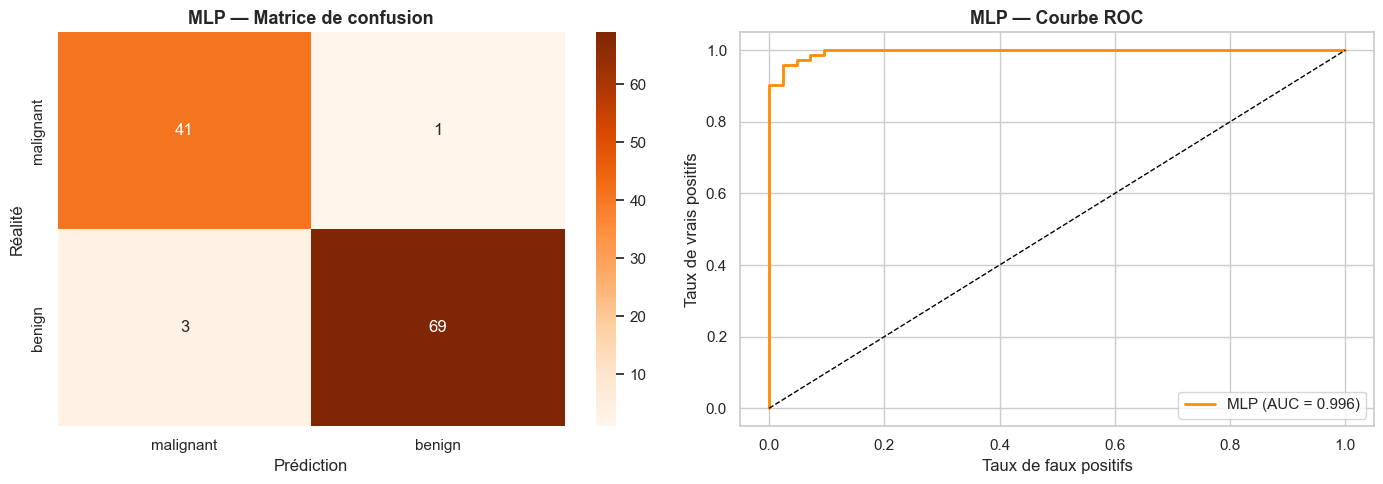

In [30]:
# Confusion matrix + ROC
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names, ax=axes[0])
axes[0].set_title('MLP — Matrice de confusion', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prédiction')
axes[0].set_ylabel('Réalité')

fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)
axes[1].plot(fpr_mlp, tpr_mlp, color='darkorange', lw=2, label=f'MLP (AUC = {auc_mlp:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('MLP — Courbe ROC', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Taux de faux positifs')
axes[1].set_ylabel('Taux de vrais positifs')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

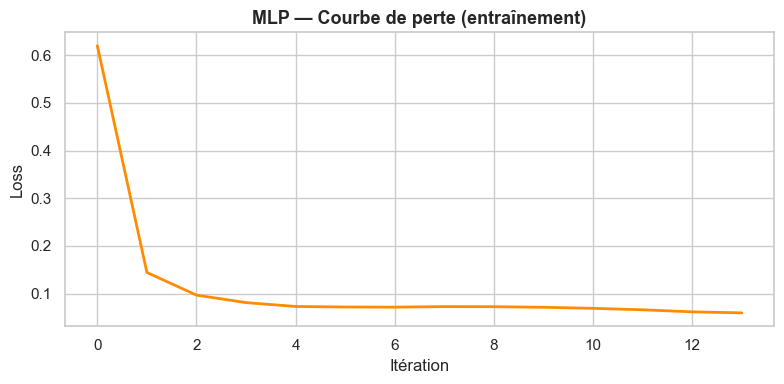

In [31]:
# Training loss curve of best MLP
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_best.loss_curve_, color='darkorange', lw=2)
ax.set_title('MLP — Courbe de perte (entraînement)', fontsize=13, fontweight='bold')
ax.set_xlabel('Itération')
ax.set_ylabel('Loss')
plt.tight_layout()
plt.show()

---
## 6. Comparaison des Modèles

In [32]:
# Summary table
from sklearn.metrics import f1_score, precision_score, recall_score

results = {
    'Modèle'   : ['SVM', 'Random Forest', 'MLP'],
    'Accuracy' : [acc_svm, acc_rf, acc_mlp],
    'ROC-AUC'  : [auc_svm, auc_rf, auc_mlp],
    'Precision': [
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_mlp)
    ],
    'Recall'   : [
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_mlp)
    ],
    'F1-Score' : [
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_mlp)
    ]
}

results_df = pd.DataFrame(results).set_index('Modèle')
results_df = results_df.round(4)
print('=== Tableau comparatif des modèles ===')
results_df

=== Tableau comparatif des modèles ===


,Accuracy,ROC-AUC,Precision,Recall,F1-Score
Modèle,,,,,
SVM,0.9825,0.9937,0.9861,0.9861,0.9861
Random Forest,0.9561,0.9931,0.9589,0.9722,0.9655
MLP,0.9649,0.9957,0.9857,0.9583,0.9718


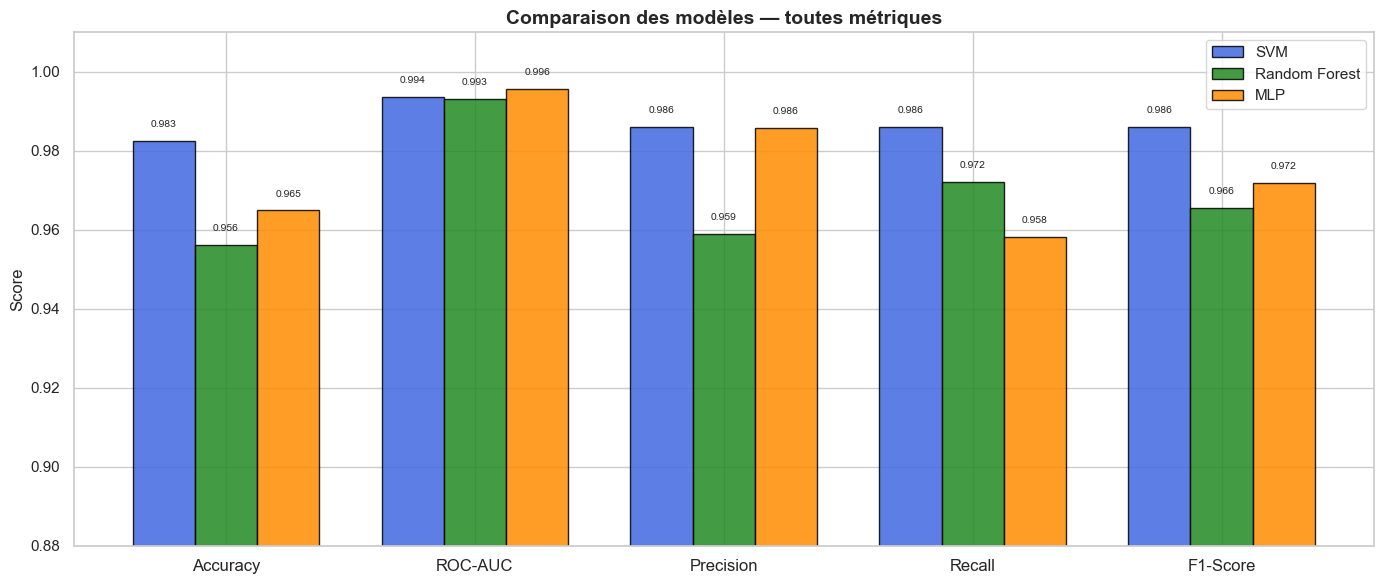

In [33]:
# Bar chart comparison
metrics = ['Accuracy', 'ROC-AUC', 'Precision', 'Recall', 'F1-Score']
models  = results_df.index.tolist()
colors  = ['royalblue', 'forestgreen', 'darkorange']

x    = np.arange(len(metrics))
w    = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
for i, (model, color) in enumerate(zip(models, colors)):
    vals = results_df.loc[model, metrics].values
    bars = ax.bar(x + i * w, vals, w, label=model, color=color, alpha=0.85, edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + w)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0.88, 1.01)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des modèles — toutes métriques', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

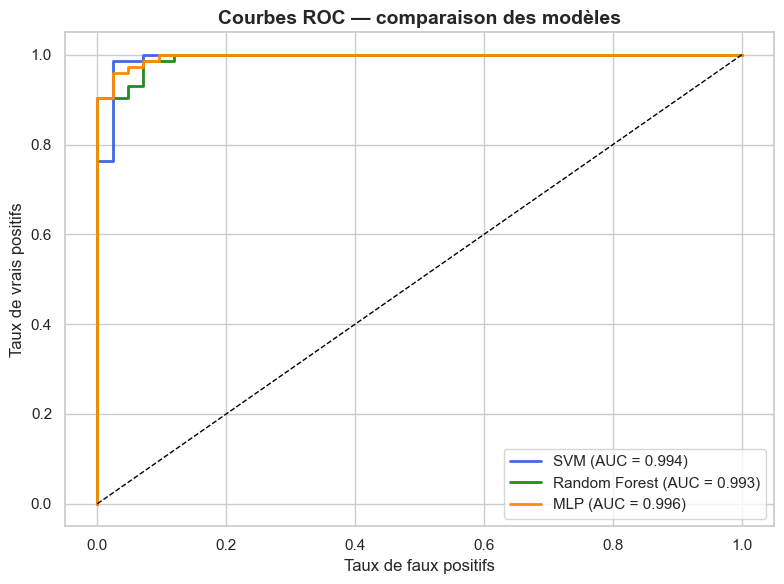

In [34]:
# Overlay ROC curves for all models
fig, ax = plt.subplots(figsize=(8, 6))

for (fpr_c, tpr_c, auc_c, label, color) in [
    (roc_curve(y_test, y_prob_svm)[0], roc_curve(y_test, y_prob_svm)[1], auc_svm, 'SVM', 'royalblue'),
    (fpr_rf, tpr_rf, auc_rf, 'Random Forest', 'forestgreen'),
    (fpr_mlp, tpr_mlp, auc_mlp, 'MLP', 'darkorange'),
]:
    ax.plot(fpr_c, tpr_c, lw=2, color=color, label=f'{label} (AUC = {auc_c:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_title('Courbes ROC — comparaison des modèles', fontsize=14, fontweight='bold')
ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

---
## 7. Conclusion

| Critère | SVM | Random Forest | MLP |
|---|---|---|---|
| Interprétabilité | Faible | Moyenne (feature importance) | Faible |
| Besoin de scaling | Oui | Non | Oui |
| Temps d'entraînement | Moyen | Moyen | Élevé |
| Performance (test) | ★★★★★ | ★★★★☆ | ★★★★☆ |

- **SVM** obtient généralement la meilleure précision sur ce dataset grâce au noyau RBF.
- **Random Forest** offre une bonne interprétabilité via l'importance des variables.
- **MLP** est compétitif mais plus coûteux à entraîner et sensible aux hyperparamètres.

Pour un contexte médical, le **Recall** (sensibilité) pour la classe maligne est la métrique la plus critique — un faux négatif (tumeur maligne classée bénigne) est bien plus grave qu'un faux positif.